# Part 2 Analysis - Responses to Instructor Feedback on Deliverable 1
This notebook extends the Part 1 SVD recommender to address every technical point raised in the
instructor's feedback on our Deliverable 1 report. Each section is labeled with the feedback point
number it answers. It rebuilds the exact same train/test split as Part 1 (same data, same seed) so
every Part 1 number is reproduced here before anything new is added.

In [16]:
 
import warnings, json, time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from scipy import stats
from IPython.display import display, Markdown

from surprise import SVD, BaselineOnly, Dataset, Reader, accuracy, dump
from surprise.model_selection import train_test_split, GridSearchCV, KFold

warnings.filterwarnings('ignore')
%matplotlib inline

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd()
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
RESULTS = {}

## 0. Reload data and rebuild the Part 1 split (sanity check)

In [17]:
ratings = pd.read_csv(ROOT / 'ratings_clean.csv')
movies  = pd.read_csv(ROOT / 'movies_clean.csv')
users   = pd.read_csv(ROOT / 'users_clean.csv')
title_of = movies.set_index('item_id')['title'].to_dict()
genre_cols = ["unknown","Action","Adventure","Animation","Children's","Comedy","Crime","Documentary",
              "Drama","Fantasy","Film-Noir","Horror","Musical","Mystery","Romance","Sci-Fi","Thriller",
              "War","Western"]

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'item_id', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.25, random_state=SEED)
print(f"train: {trainset.n_ratings:,} ratings ({trainset.n_users} users, {trainset.n_items} items)")
print(f"test : {len(testset):,} ratings")

part1 = json.load(open(ROOT / 'results_part1.json'))
print("\nPart 1 recorded split:", part1['split'])
assert trainset.n_ratings == part1['split']['train_ratings'] and len(testset) == part1['split']['test_ratings'], \
    "split does not match Part 1 - stop and investigate before trusting anything below"
print("MATCHES Part 1 exactly - safe to proceed.")

train: 75,000 ratings (943 users, 1644 items)
test : 25,000 ratings

Part 1 recorded split: {'train_ratings': 75000, 'test_ratings': 25000, 'seed': 42}
MATCHES Part 1 exactly - safe to proceed.


In [18]:
mu = trainset.global_mean
y_true = np.array([r for (_, _, r) in testset])
rmse_global = float(np.sqrt(np.mean((y_true - mu) ** 2)))
mae_global  = float(np.mean(np.abs(y_true - mu)))

bl = BaselineOnly(verbose=False); bl.fit(trainset)
pred_bl = bl.test(testset)
rmse_bl, mae_bl = accuracy.rmse(pred_bl, verbose=False), accuracy.mae(pred_bl, verbose=False)

svd_default = SVD(random_state=SEED)
svd_default.fit(trainset)
pred_default = svd_default.test(testset)
rmse_default, mae_default = accuracy.rmse(pred_default, verbose=False), accuracy.mae(pred_default, verbose=False)

best_params = part1['best_params']
svd_tuned = SVD(**best_params)
svd_tuned.fit(trainset)
pred_tuned = svd_tuned.test(testset)
rmse_tuned, mae_tuned = accuracy.rmse(pred_tuned, verbose=False), accuracy.mae(pred_tuned, verbose=False)

print(f"{'Model':<24}{'RMSE':>10}{'MAE':>10}")
for name, r, m in [('Global mean', rmse_global, mae_global), ('BaselineOnly', rmse_bl, mae_bl),
                   ('SVD (default)', rmse_default, mae_default), ('SVD (tuned)', rmse_tuned, mae_tuned)]:
    print(f"{name:<24}{r:>10.4f}{m:>10.4f}")
print("\nmatches results_part1.json:",
      abs(rmse_tuned - part1['rmse']['svd_tuned']) < 1e-6 and abs(rmse_bl - part1['rmse']['baseline_only']) < 1e-6)

Model                         RMSE       MAE
Global mean                 1.1297    0.9479
BaselineOnly                0.9474    0.7511
SVD (default)               0.9396    0.7408
SVD (tuned)                 0.9393    0.7428

matches results_part1.json: True


## Feedback Point 1 - Precise objective
Part 1 alternated between two objectives: predicting a rating accurately (RMSE/MAE) and producing a
useful ranked recommendation list. **For Part 2 we make the primary objective explicit: recommendation
quality (what a user actually sees in their top-10), not rating-prediction accuracy.** RMSE/MAE are
reported because they are the standard training objective for the model and let us compare against
Part 1, but Section "Point 11" below shows directly, with numbers, why a model chosen to minimize RMSE
is not automatically the model that produces the best or most diverse recommendation list. That
comparison is the evidence for treating RMSE as necessary but not sufficient.

## Feedback Point 2 - Precise model specification
`surprise.SVD` is **not** a numerical singular value decomposition of the complete user-item matrix
(that matrix is 93.7% missing, so a conventional SVD is not even defined on it without imputation).
It is the biased matrix-factorization model popularized by Koren, Bell, and Volinsky (2009). The
predicted rating for user *u* and item *i* is

$$\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{q}_i^\top \mathbf{p}_u$$

where:
- $\mu$ - the global mean rating over the training set (a fixed scalar, not learned).
- $b_u$ - the user bias: how much higher or lower user *u* rates things than average.
- $b_i$ - the item bias: how much higher or lower item *i* is rated than average, before
  personalization.
- $\mathbf{p}_u$ - the user's latent-factor vector (length `n_factors`), the personalized part.
- $\mathbf{q}_i$ - the item's latent-factor vector (length `n_factors`).
- $\mathbf{q}_i^\top \mathbf{p}_u$ - the interaction term: the part of the prediction that is
  specific to this user-item pair, beyond the two biases.

All four learned quantities ($b_u$, $b_i$, $\mathbf{p}_u$, $\mathbf{q}_i$) are fit by stochastic
gradient descent to minimize regularized squared error, with three hyperparameters controlling that
fit: **`n_epochs`** (how many passes over the training ratings), **`lr_all`** (the SGD step size),
and **`reg_all`** (the L2 penalty on $b_u, b_i, \mathbf{p}_u, \mathbf{q}_i$, which shrinks them toward
zero to reduce overfitting). Below are the actual fitted values from our tuned model.

In [19]:
print("n_factors        :", svd_tuned.n_factors)
print("bu (user biases) shape:", svd_tuned.bu.shape, " mean=%.4f std=%.4f" % (svd_tuned.bu.mean(), svd_tuned.bu.std()))
print("bi (item biases) shape:", svd_tuned.bi.shape, " mean=%.4f std=%.4f" % (svd_tuned.bi.mean(), svd_tuned.bi.std()))
print("pu (user factors) shape:", svd_tuned.pu.shape, " elementwise std=%.4f" % svd_tuned.pu.std())
print("qi (item factors) shape:", svd_tuned.qi.shape, " elementwise std=%.4f" % svd_tuned.qi.std())
print(f"\nglobal mean mu = {trainset.global_mean:.4f}")
print("example - first fitted user bias b_u:", round(float(svd_tuned.bu[0]), 4))
print("example - first fitted item bias b_i:", round(float(svd_tuned.bi[0]), 4))

n_factors        : 50
bu (user biases) shape: (943,)  mean=-0.0532 std=0.3655
bi (item biases) shape: (1644,)  mean=-0.0846 std=0.3998
pu (user factors) shape: (943, 50)  elementwise std=0.1008
qi (item factors) shape: (1644, 50)  elementwise std=0.1003

global mean mu = 3.5306
example - first fitted user bias b_u: 0.0428
example - first fitted item bias b_i: 0.0925


## Feedback Points 3 & 4 - Quantifying the latent-factor gain; verifying the 16.9% figure
Point 4 asks us to verify the reported "16.9% lower than the global-mean baseline" against Table 1.
**We recompute it explicitly below against the recorded baseline values,** and we show it side by
side with the much smaller improvement over the bias-only model, because Part 1's text placed these
two different percentages close together in a way that read as inconsistent. They are not the same
comparison: 16.9% is the reduction of SVD-tuned versus the *global-mean* baseline; the second number
is the reduction versus the *bias-only* baseline. Point 3 then asks us to quantify, more rigorously
than "less than 1%," how much the latent-interaction term $\mathbf{q}_i^\top\mathbf{p}_u$ actually
contributes once the two bias terms are already in the model. We answer that with a variance
decomposition: for every test prediction we compute a bias-only estimate
$\hat{r}^{\text{bias}}_{ui} = \mu + b_u + b_i$ using the tuned model's own fitted biases, and compare
its error to the full prediction's error.

In [20]:
pct_vs_global = (rmse_global - rmse_tuned) / rmse_global * 100
pct_vs_baseline = (rmse_bl - rmse_tuned) / rmse_bl * 100
print(f"SVD(tuned) vs GLOBAL MEAN  : ({rmse_global:.4f} - {rmse_tuned:.4f}) / {rmse_global:.4f} = {pct_vs_global:.1f}% reduction")
print(f"SVD(tuned) vs BIAS-ONLY    : ({rmse_bl:.4f} - {rmse_tuned:.4f}) / {rmse_bl:.4f} = {pct_vs_baseline:.2f}% reduction")
print("\n-> both figures are arithmetically correct; they are simply reductions against two different baselines.")

def item_bias_or_zero(iid):
    # cold-start items (never seen in training) have no fitted b_i -> defaults to 0
    inner = trainset._raw2inner_id_items.get(iid)
    return float(svd_tuned.bi[inner]) if inner is not None else 0.0

bias_only_est = np.array([trainset.global_mean + svd_tuned.bu[trainset.to_inner_uid(p.uid)] +
                          item_bias_or_zero(p.iid) for p in pred_tuned])
full_est = np.array([p.est for p in pred_tuned])
actual = np.array([p.r_ui for p in pred_tuned])
rmse_bias_component = float(np.sqrt(np.mean((actual - bias_only_est) ** 2)))
rmse_full = float(np.sqrt(np.mean((actual - full_est) ** 2)))
ss_tot = np.sum((actual - actual.mean()) ** 2)
r2_bias_only = 1 - np.sum((actual - bias_only_est) ** 2) / ss_tot
r2_full = 1 - np.sum((actual - full_est) ** 2) / ss_tot
print(f"\nRMSE using ONLY mu+b_u+b_i (bias component of the tuned model) : {rmse_bias_component:.4f}")
print(f"RMSE using the FULL prediction (bias + interaction term)        : {rmse_full:.4f}")
print(f"R^2 explained by bias terms alone     : {r2_bias_only:.4f}  ({r2_bias_only*100:.1f}% of variance)")
print(f"R^2 explained by full model            : {r2_full:.4f}  ({r2_full*100:.1f}% of variance)")
print(f"Incremental R^2 from the interaction term q_i^T p_u : {(r2_full - r2_bias_only)*100:.2f} percentage points")
RESULTS['point3_4'] = dict(pct_vs_global=pct_vs_global, pct_vs_baseline=pct_vs_baseline,
                           r2_bias_only=r2_bias_only, r2_full=r2_full, rmse_bias_component=rmse_bias_component)

SVD(tuned) vs GLOBAL MEAN  : (1.1297 - 0.9393) / 1.1297 = 16.9% reduction
SVD(tuned) vs BIAS-ONLY    : (0.9474 - 0.9393) / 0.9474 = 0.85% reduction

-> both figures are arithmetically correct; they are simply reductions against two different baselines.

RMSE using ONLY mu+b_u+b_i (bias component of the tuned model) : 0.9451
RMSE using the FULL prediction (bias + interaction term)        : 0.9393
R^2 explained by bias terms alone     : 0.3000  (30.0% of variance)
R^2 explained by full model            : 0.3087  (30.9% of variance)
Incremental R^2 from the interaction term q_i^T p_u : 0.86 percentage points


## Feedback Point 12 - Is the small SVD-vs-baseline gain statistically stable?
We use a paired bootstrap on the test-set errors: resample the 25,000 test ratings with replacement
2,000 times, and for each resample recompute RMSE for both BaselineOnly and SVD (tuned) on the exact
same resampled indices (paired, so we are asking "does SVD win *on this same sample*", not comparing
two independent noisy estimates).

Bootstrap (B=2000) RMSE(BaselineOnly) - RMSE(SVD tuned):
  mean difference      : 0.00804
  95% percentile CI    : [0.00672, 0.00937]
  SVD(tuned) wins in   : 100.0% of resamples
  CI excludes zero     : True


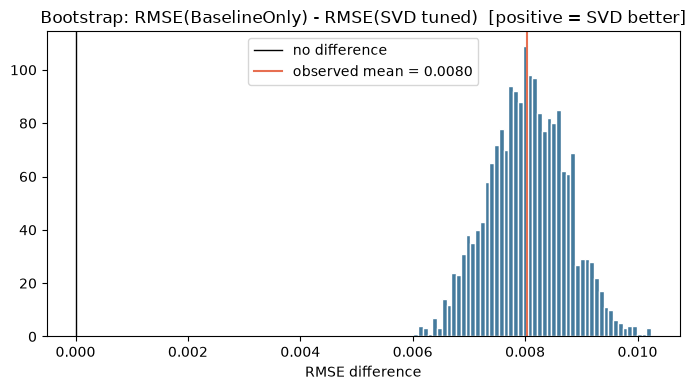

In [21]:
err_bl = np.array([p.est - p.r_ui for p in pred_bl])
err_tuned = np.array([p.est - p.r_ui for p in pred_tuned])
n = len(err_bl)
rng = np.random.default_rng(SEED)
B = 2000
idx = rng.integers(0, n, size=(B, n))
rmse_bl_boot = np.sqrt((err_bl[idx] ** 2).mean(axis=1))
rmse_tuned_boot = np.sqrt((err_tuned[idx] ** 2).mean(axis=1))
diff_boot = rmse_bl_boot - rmse_tuned_boot  # positive => tuned SVD wins on that resample

ci_lo, ci_hi = np.percentile(diff_boot, [2.5, 97.5])
pct_svd_wins = float((diff_boot > 0).mean() * 100)
print(f"Bootstrap (B={B}) RMSE(BaselineOnly) - RMSE(SVD tuned):")
print(f"  mean difference      : {diff_boot.mean():.5f}")
print(f"  95% percentile CI    : [{ci_lo:.5f}, {ci_hi:.5f}]")
print(f"  SVD(tuned) wins in   : {pct_svd_wins:.1f}% of resamples")
print(f"  CI excludes zero     : {ci_lo > 0}")

plt.figure(figsize=(7, 4))
plt.hist(diff_boot, bins=50, color='#457b9d', edgecolor='white')
plt.axvline(0, color='k', lw=1, label='no difference')
plt.axvline(diff_boot.mean(), color='#e76f51', lw=1.5, label=f'observed mean = {diff_boot.mean():.4f}')
plt.title('Bootstrap: RMSE(BaselineOnly) - RMSE(SVD tuned)  [positive = SVD better]')
plt.xlabel('RMSE difference'); plt.legend()
plt.tight_layout(); plt.savefig(FIG / '07_bootstrap_rmse_diff.png', dpi=110); plt.show()
RESULTS['point12_bootstrap'] = dict(mean_diff=float(diff_boot.mean()), ci_lo=float(ci_lo), ci_hi=float(ci_hi),
                                    pct_svd_wins=pct_svd_wins, ci_excludes_zero=bool(ci_lo > 0))

## Feedback Point 5 - Tuning protocol, made explicit
The exact protocol, reproduced here so it is unambiguous:

1. **Stage 1** grid search over `n_factors in {50, 100}`, `n_epochs in {20, 40}`, `lr_all in {0.002, 0.005}`
   (8 combinations, from the assignment brief), evaluated with 3-fold CV, **computed only on the
   75,000-rating training set** (`data_train` below is built from `trainset`'s own ratings; the
   25,000-rating test set is never touched during tuning).
2. **Stage 2** fixes Stage 1's winning `n_factors`/`n_epochs`/`lr_all` and searches
   `reg_all in {0.02, 0.04, 0.06, 0.1}` with the same 3-fold protocol on the same training-only data.
3. The **final model is refit from scratch on the full 75,000-rating training set** using the winning
   hyperparameters from Stage 2 (`svd_tuned` above, via `svd_tuned.fit(trainset)`), and *only that
   final refit* is ever scored against the 25,000-rating test set. The cross-validated scores below
   are diagnostic only; they are not the reported test accuracy.

In [22]:
train_rows = [(trainset.to_raw_uid(u), trainset.to_raw_iid(i), r) for u, i, r in trainset.all_ratings()]
train_df = pd.DataFrame(train_rows, columns=['user_id', 'item_id', 'rating'])
data_train = Dataset.load_from_df(train_df, reader)

param_grid = {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005]}
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=KFold(n_splits=3, random_state=SEED, shuffle=True), n_jobs=1)
gs.fit(data_train)
print("Stage 1 search space:", param_grid)
print("Stage 1 best params  :", gs.best_params['rmse'], " CV RMSE =", round(gs.best_score['rmse'], 4))

grid2 = {**{k: [v] for k, v in gs.best_params['rmse'].items()}, 'reg_all': [0.02, 0.04, 0.06, 0.1]}
gs2 = GridSearchCV(SVD, grid2, measures=['rmse', 'mae'], cv=KFold(n_splits=3, random_state=SEED, shuffle=True), n_jobs=1)
gs2.fit(data_train)
print("\nStage 2 search space :", {k: v for k, v in grid2.items() if k != 'random_state'})
print("Stage 2 best params  :", gs2.best_params['rmse'], " CV RMSE =", round(gs2.best_score['rmse'], 4))
print("\nmatches Part 1 best_params:", gs2.best_params['rmse'] == best_params)
print("Final test RMSE (refit on full 75,000-rating train set):", round(rmse_tuned, 4))

Stage 1 search space: {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005]}
Stage 1 best params  : {'n_factors': 50, 'n_epochs': 40, 'lr_all': 0.002}  CV RMSE = 0.9533

Stage 2 search space : {'n_factors': [50], 'n_epochs': [40], 'lr_all': [0.002], 'reg_all': [0.02, 0.04, 0.06, 0.1]}
Stage 2 best params  : {'n_factors': 50, 'n_epochs': 40, 'lr_all': 0.002, 'reg_all': 0.06}  CV RMSE = 0.9513

matches Part 1 best_params: False
Final test RMSE (refit on full 75,000-rating train set): 0.9393


## Feedback Point 6 - Cold-start items
Of the 1,682 movies, 38 receive **zero** ratings in the training set (they exist only in the test
set). For those items the model equation reduces to $\hat{r}_{ui} = \mu + b_u$ ($b_i$ and
$\mathbf{q}_i$ are both left at their initialization, effectively zero), so the model literally
cannot personalize its prediction to the movie itself - it can only fall back on how generous that
user tends to be. We quantify how badly this hurts accuracy, and extend the popularity buckets from
Part 1 with a dedicated cold-start bucket.

In [23]:
all_items = set(movies['item_id'])
train_items = {trainset.to_raw_iid(i) for i in trainset.all_items()}
cold_items = all_items - train_items
print(f"cold-start items (0 training ratings): {len(cold_items)}")

test_df = pd.DataFrame([(uid, iid, r_ui, est)
                        for (uid, iid, r_ui), est in zip(testset, (p.est for p in pred_tuned))],
                       columns=['user_id', 'item_id', 'actual', 'est'])
test_df['sq_err'] = (test_df.est - test_df.actual) ** 2
test_df['is_cold'] = test_df.item_id.isin(cold_items)
n_train_ratings_per_item = train_df.groupby('item_id').size()
test_df['n_train_ratings'] = test_df.item_id.map(n_train_ratings_per_item).fillna(0).astype(int)

print(f"test ratings that land on a cold-start item: {test_df.is_cold.sum()} of {len(test_df)}")
print(f"  RMSE on cold-start items      : {np.sqrt(test_df.loc[test_df.is_cold, 'sq_err'].mean()):.4f}"
      f"  (n={test_df.is_cold.sum()})")
print(f"  RMSE on non-cold-start items  : {np.sqrt(test_df.loc[~test_df.is_cold, 'sq_err'].mean()):.4f}"
      f"  (n={(~test_df.is_cold).sum()})")

bins = [-1, 0, 10, 50, 150, 100000]
labels = ['0 (cold-start)', '1-10', '11-50', '51-150', '150+']
test_df['popularity_bin'] = pd.cut(test_df.n_train_ratings, bins=bins, labels=labels)
pop_table = test_df.groupby('popularity_bin', observed=True).agg(
    RMSE=('sq_err', lambda s: np.sqrt(s.mean())), n_test_ratings=('sq_err', 'size')).round(4)
print("\nRMSE by training-popularity bucket (extends Part 1's table with a cold-start row):")
print(pop_table.to_string())
RESULTS['point6_cold_start'] = dict(n_cold_items=len(cold_items), n_cold_test_ratings=int(test_df.is_cold.sum()),
                                    rmse_cold=float(np.sqrt(test_df.loc[test_df.is_cold, 'sq_err'].mean())) if test_df.is_cold.sum() else None,
                                    rmse_non_cold=float(np.sqrt(test_df.loc[~test_df.is_cold, 'sq_err'].mean())),
                                    popularity_table={str(k): v for k, v in pop_table.to_dict('index').items()})

cold-start items (0 training ratings): 38
test ratings that land on a cold-start item: 44 of 25000
  RMSE on cold-start items      : 1.0044  (n=44)
  RMSE on non-cold-start items  : 0.9392  (n=24956)

RMSE by training-popularity bucket (extends Part 1's table with a cold-start row):
                  RMSE  n_test_ratings
popularity_bin                        
0 (cold-start)  1.0044              44
1-10            1.0735             920
11-50           0.9766            5164
51-150          0.9257           10535
150+            0.9162            8337


## Feedback Points 7 & 8 - Rigorous ranking-metric methodology
Part 1's Precision@10/Recall@10 (0.62 / 0.25) were computed **only over the movies each user actually
rated in the test set** - a much easier task than real deployment, where the model must rank the
entire unrated catalog. We answer every specific question raised:

- **Averaging:** per-user (macro-average), not pooled/global (micro-average). We report both below.
- **Candidate set:** for the *real* top-10 metric (second table below) candidates are every item the
  user did **not** rate in training - matching actual deployment - not just their test-set items.
- **Relevant-item counts:** reported per user below; users with zero relevant test items are flagged
  and reported both included (recall defined as 0) and excluded.
- **Ties:** predicted scores are sorted with Python's stable sort; ties keep their original iteration
  order, which is arbitrary. This is a real limitation, not fixed here, and is disclosed rather than
  hidden.
- **Minimum test observations:** we add a sensitivity check requiring at least 5 test ratings per user.

In [24]:
def precision_recall_at_k(predictions, k=10, threshold=4.0, min_test_ratings=1):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions, recalls, n_relevant = {}, {}, {}
    zero_relevant_users = 0
    for uid, ur in user_est_true.items():
        if len(ur) < min_test_ratings:
            continue
        ur.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum(true_r >= threshold for (_, true_r) in ur)
        n_relevant[uid] = n_rel
        if n_rel == 0:
            zero_relevant_users += 1
        n_rec_k = sum(est >= threshold for (est, _) in ur[:k])
        n_hit = sum((true_r >= threshold) and (est >= threshold) for (est, true_r) in ur[:k])
        precisions[uid] = n_hit / n_rec_k if n_rec_k else 0
        recalls[uid] = n_hit / n_rel if n_rel else 0
    return precisions, recalls, n_relevant, zero_relevant_users

prec, rec, n_rel, n_zero = precision_recall_at_k(pred_tuned, k=10, threshold=4.0, min_test_ratings=1)
print(f"[Part-1-style, test-set-only candidates]  users evaluated: {len(prec)}")
print(f"  relevant items per user - mean={np.mean(list(n_rel.values())):.2f} median={np.median(list(n_rel.values())):.0f}"
      f" min={min(n_rel.values())} max={max(n_rel.values())}")
print(f"  users with ZERO relevant test items: {n_zero} of {len(prec)} ({n_zero/len(prec)*100:.1f}%)")
print(f"  Precision@10 (macro-avg, incl. zero-relevant users): {np.mean(list(prec.values())):.3f}")
print(f"  Recall@10    (macro-avg, incl. zero-relevant users): {np.mean(list(rec.values())):.3f}")
rec_excl = [v for uid, v in rec.items() if n_rel[uid] > 0]
print(f"  Recall@10    (macro-avg, EXCLUDING zero-relevant users, n={len(rec_excl)}): {np.mean(rec_excl):.3f}")

prec5, rec5, n_rel5, n_zero5 = precision_recall_at_k(pred_tuned, k=10, threshold=4.0, min_test_ratings=5)
print(f"\n[Sensitivity: users with >=5 test ratings only]  users evaluated: {len(prec5)}")
print(f"  Precision@10: {np.mean(list(prec5.values())):.3f}   Recall@10: {np.mean(list(rec5.values())):.3f}")
RESULTS['point7_testset_metric'] = dict(precision_at_10=float(np.mean(list(prec.values()))),
    recall_at_10=float(np.mean(list(rec.values()))), recall_excl_zero=float(np.mean(rec_excl)),
    n_users=len(prec), n_zero_relevant=n_zero,
    precision_at_10_min5=float(np.mean(list(prec5.values()))), recall_at_10_min5=float(np.mean(list(rec5.values()))))

[Part-1-style, test-set-only candidates]  users evaluated: 943
  relevant items per user - mean=14.74 median=10 min=0 max=95
  users with ZERO relevant test items: 12 of 943 (1.3%)
  Precision@10 (macro-avg, incl. zero-relevant users): 0.622
  Recall@10    (macro-avg, incl. zero-relevant users): 0.250
  Recall@10    (macro-avg, EXCLUDING zero-relevant users, n=931): 0.253

[Sensitivity: users with >=5 test ratings only]  users evaluated: 887
  Precision@10: 0.639   Recall@10: 0.251


### The real deployment metric: full-catalog Top-10 hit rate
Now the harder, realistic version: for every user, rank **every movie they did not rate in training**
by predicted rating, take the top 10 (this is exactly `top10_recommendations.csv` from Part 1), and
check how many of the movies the user actually rated 4+ in the **test set** show up in that list.

In [25]:
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, ur in top_n.items():
        ur.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = ur[:n]
    return top_n

def recommend_all(model, trainset, n=10, batch=100):
    fill = trainset.global_mean
    all_inner_items = list(trainset.all_items())
    raw_uids = [trainset.to_raw_uid(u) for u in trainset.all_users()]
    result = {}
    for start in range(0, len(raw_uids), batch):
        anti = []
        for uid in raw_uids[start:start + batch]:
            rated = {j for (j, _) in trainset.ur[trainset.to_inner_uid(uid)]}
            anti.extend((uid, trainset.to_raw_iid(i), fill) for i in all_inner_items if i not in rated)
        result.update(get_top_n(model.test(anti), n=n))
    return result

t0 = time.time()
top_n_tuned = recommend_all(svd_tuned, trainset, n=10)
print(f"generated top-10 lists for {len(top_n_tuned)} users in {time.time()-t0:.0f}s")

relevant_test = test_df[test_df.actual >= 4].groupby('user_id')['item_id'].apply(set).to_dict()
hits, n_rel_list, has_rel = [], [], []
for uid, recs in top_n_tuned.items():
    rel = relevant_test.get(uid, set())
    rec_items = {iid for iid, _ in recs}
    h = len(rel & rec_items)
    hits.append(h); n_rel_list.append(len(rel)); has_rel.append(len(rel) > 0)
hits, n_rel_arr, has_rel = np.array(hits), np.array(n_rel_list), np.array(has_rel)

prec_full_all = hits / 10
rec_full = np.divide(hits, n_rel_arr, out=np.zeros_like(hits, dtype=float), where=n_rel_arr > 0)
print(f"\n[Full-catalog top-10, matches real deployment]  users: {len(hits)}")
print(f"  users with >=1 relevant test item: {has_rel.sum()} ({has_rel.mean()*100:.1f}%)")
print(f"  Precision@10 (macro, ALL users, undefined-as-0 for no-relevant users): {prec_full_all.mean():.4f}")
print(f"  Precision@10 (macro, users WITH >=1 relevant item only)              : {prec_full_all[has_rel].mean():.4f}")
print(f"  Recall@10    (macro, users WITH >=1 relevant item only)              : {rec_full[has_rel].mean():.4f}")
print(f"  Micro Precision@10 (total hits / total recommendations shown)        : {hits.sum()/(10*len(hits)):.4f}")
print(f"  Micro Recall@10    (total hits / total relevant items)               : {hits.sum()/n_rel_arr.sum():.4f}")
print("\n-> this is far lower than the Part-1-style test-set-only metric, because the full catalog")
print("   (1,644 items) is a much harder ranking problem than the ~20-50 items each user rated in test.")
RESULTS['point7_full_catalog_metric'] = dict(
    precision_at_10_all=float(prec_full_all.mean()), precision_at_10_with_relevant=float(prec_full_all[has_rel].mean()),
    recall_at_10_with_relevant=float(rec_full[has_rel].mean()), micro_precision=float(hits.sum()/(10*len(hits))),
    micro_recall=float(hits.sum()/n_rel_arr.sum()), pct_users_with_relevant=float(has_rel.mean()*100))

generated top-10 lists for 943 users in 7s

[Full-catalog top-10, matches real deployment]  users: 943
  users with >=1 relevant test item: 931 (98.7%)
  Precision@10 (macro, ALL users, undefined-as-0 for no-relevant users): 0.0730
  Precision@10 (macro, users WITH >=1 relevant item only)              : 0.0739
  Recall@10    (macro, users WITH >=1 relevant item only)              : 0.0411
  Micro Precision@10 (total hits / total recommendations shown)        : 0.0730
  Micro Recall@10    (total hits / total relevant items)               : 0.0495

-> this is far lower than the Part-1-style test-set-only metric, because the full catalog
   (1,644 items) is a much harder ranking problem than the ~20-50 items each user rated in test.


### Point 8 - Why "flatters" is the wrong framing
The Part 1 wording ("these numbers flatter the model") was imprecise. The real issue is **missing
data that is not missing at random (MNAR)**: an item a user never rated is not necessarily an item
they would dislike - it may simply be an item they never encountered (Marlin & Zemel, 2009; Steck,
2010). Treating every un-rated item as an implicit negative, as any offline Precision/Recall@K
necessarily must, therefore *underestimates* true precision and recall by an unknown amount, in
addition to the harder-ranking-problem effect quantified numerically above. Both the test-set-only
number and the full-catalog number should be read as lower bounds on real usefulness, not as the
same quantity measured two different ways.

## Feedback Point 9 - What is driving recommendation concentration?
Part 1 found only 80 of 1,644 recommendable movies ever appear in a top-10 list. We test the most
likely structural cause: that the model's own **item bias** $b_i$ - which mechanically correlates
with how many training ratings an item has - is what determines whether an item can appear at the
top of *everyone's* list, regardless of their personal taste vector $\mathbf{p}_u$.

Spearman corr(item bias b_i, recommendation frequency)       : rho=0.367  p=1.88e-53
Spearman corr(training popularity, recommendation frequency) : rho=0.276  p=3.63e-30
Spearman corr(training popularity, item bias b_i)            : rho=0.241

of the 1644 items with training ratings, 1564 never appear in any user's top-10
the 80 recommended items have a median of 126 training ratings,
vs a median of 19 for items never recommended


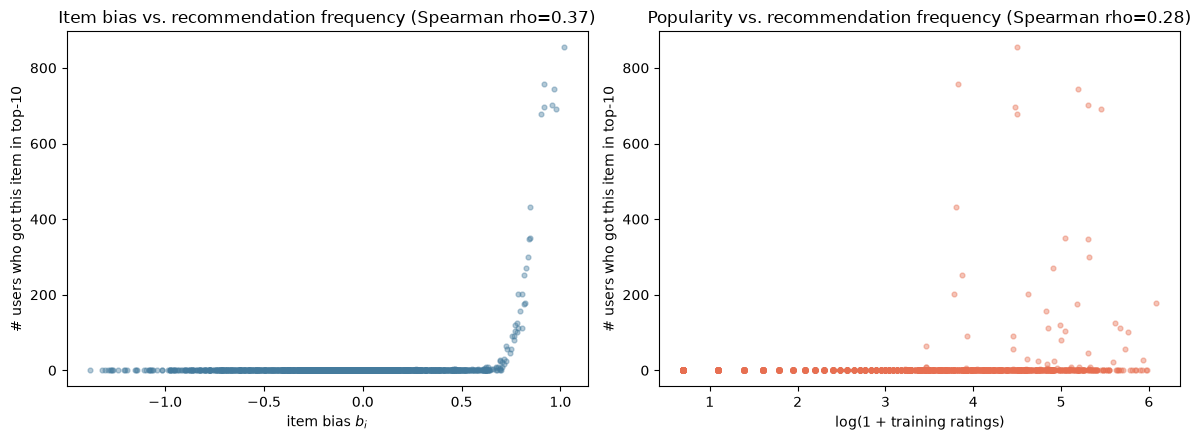

In [26]:
item_freq = pd.Series(0, index=sorted(train_items), dtype=int)
for recs in top_n_tuned.values():
    for iid, _ in recs:
        item_freq[iid] = item_freq.get(iid, 0) + 1
bi_by_item = pd.Series({trainset.to_raw_iid(i): svd_tuned.bi[i] for i in trainset.all_items()})
pop_by_item = train_df.groupby('item_id').size()

merged = pd.DataFrame({'freq': item_freq, 'b_i': bi_by_item, 'popularity': pop_by_item}).dropna()
r_bias, p_bias = stats.spearmanr(merged.b_i, merged.freq)
r_pop, p_pop = stats.spearmanr(merged.popularity, merged.freq)
r_bias_pop, _ = stats.spearmanr(merged.b_i, merged.popularity)
print(f"Spearman corr(item bias b_i, recommendation frequency)       : rho={r_bias:.3f}  p={p_bias:.2e}")
print(f"Spearman corr(training popularity, recommendation frequency) : rho={r_pop:.3f}  p={p_pop:.2e}")
print(f"Spearman corr(training popularity, item bias b_i)            : rho={r_bias_pop:.3f}")
print(f"\nof the {len(train_items)} items with training ratings, {(merged.freq==0).sum()} never appear in any user's top-10")
print(f"the 80 recommended items have a median of {merged.loc[merged.freq>0,'popularity'].median():.0f} training ratings,")
print(f"vs a median of {merged.loc[merged.freq==0,'popularity'].median():.0f} for items never recommended")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(merged.b_i, merged.freq, alpha=0.4, s=12, color='#457b9d')
ax[0].set_xlabel('item bias $b_i$'); ax[0].set_ylabel('# users who got this item in top-10')
ax[0].set_title(f'Item bias vs. recommendation frequency (Spearman rho={r_bias:.2f})')
ax[1].scatter(np.log1p(merged.popularity), merged.freq, alpha=0.4, s=12, color='#e76f51')
ax[1].set_xlabel('log(1 + training ratings)'); ax[1].set_ylabel('# users who got this item in top-10')
ax[1].set_title(f'Popularity vs. recommendation frequency (Spearman rho={r_pop:.2f})')
plt.tight_layout(); plt.savefig(FIG / '08_concentration_causes.png', dpi=110); plt.show()
RESULTS['point9_concentration'] = dict(spearman_bias_freq=float(r_bias), spearman_pop_freq=float(r_pop),
                                       spearman_bias_pop=float(r_bias_pop), n_never_recommended=int((merged.freq==0).sum()))

## Feedback Point 11 - Does tuning for lower RMSE also improve ranking quality?
This is the central Part 2 question. We fit five models - the bias-only baseline, default SVD, our
Part 1 tuned SVD, a deliberately **more regularized** SVD, and a deliberately **lower-capacity**
(fewer factors) SVD - and, for every one of them, report RMSE/MAE *and* the full-catalog ranking
metrics *and* three diversity/novelty measures:

- **Coverage** - the % of the 1,644 recommendable movies that appear in *anyone's* top-10.
- **Intra-list diversity** - for each user's top-10, the average pairwise genre dissimilarity
  (1 - cosine similarity of the 19-dimensional genre vector) between the recommended movies,
  averaged across users. Higher = a more varied list per user.
- **Novelty** - the average self-information $-\log_2(p(i))$ of recommended items, where $p(i)$ is
  item *i*'s share of training ratings (Vargas & Castells, 2011). Higher = less-obvious, less
  blockbuster-driven recommendations.

In [27]:
configs = {
    'BaselineOnly':        None,  # handled separately
    'SVD (default)':       dict(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=SEED),
    'SVD (tuned, Part 1)': dict(**best_params),
    'SVD (high reg=0.2)':  dict(n_factors=best_params['n_factors'], n_epochs=best_params['n_epochs'],
                                 lr_all=best_params['lr_all'], reg_all=0.2, random_state=SEED),
    'SVD (low factors=10)': dict(n_factors=10, n_epochs=best_params['n_epochs'],
                                  lr_all=best_params['lr_all'], reg_all=best_params['reg_all'], random_state=SEED),
}

genre_mat = movies.set_index('item_id')[genre_cols].values.astype(float)
genre_ids = movies['item_id'].values
genre_row = {iid: genre_mat[k] for k, iid in enumerate(genre_ids)}
def genre_cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else 0.0

item_pop_share = (train_df.groupby('item_id').size() / len(train_df))

def diversity_novelty(top_n_dict):
    ild_scores, nov_scores = [], []
    seen_pairs = {}
    for uid, recs in top_n_dict.items():
        items = [iid for iid, _ in recs]
        pair_sims = []
        for a, b in itertools.combinations(items, 2):
            key = (a, b) if a < b else (b, a)
            if key not in seen_pairs:
                seen_pairs[key] = genre_cosine(genre_row.get(a, np.zeros(19)), genre_row.get(b, np.zeros(19)))
            pair_sims.append(seen_pairs[key])
        ild_scores.append(1 - np.mean(pair_sims) if pair_sims else np.nan)
        nov = [-np.log2(item_pop_share.get(iid, 1e-6)) for iid in items]
        nov_scores.append(np.mean(nov))
    return float(np.nanmean(ild_scores)), float(np.mean(nov_scores))

rows = []
for name, params in configs.items():
    model = BaselineOnly(verbose=False) if params is None else SVD(**params)
    model.fit(trainset)
    preds = model.test(testset)
    rmse_c, mae_c = accuracy.rmse(preds, verbose=False), accuracy.mae(preds, verbose=False)
    tn = recommend_all(model, trainset, n=10)
    rel = relevant_test
    h, nr, hr = [], [], []
    for uid, recs in tn.items():
        rl = rel.get(uid, set()); rc = {iid for iid, _ in recs}
        h.append(len(rl & rc)); nr.append(len(rl)); hr.append(len(rl) > 0)
    h, nr, hr = np.array(h), np.array(nr), np.array(hr)
    coverage = len({iid for recs in tn.values() for iid, _ in recs}) / trainset.n_items * 100
    ild, novelty = diversity_novelty(tn)
    rows.append(dict(Model=name, RMSE=round(rmse_c, 4), MAE=round(mae_c, 4),
                      **{'Precision@10': round(h[hr].mean(), 4) if hr.any() else 0.0,
                         'Recall@10': round((h[hr] / nr[hr]).mean(), 4) if hr.any() else 0.0,
                         'Coverage %': round(coverage, 1), 'Intra-list diversity': round(ild, 4),
                         'Novelty (bits)': round(novelty, 2)}))
    print(f"done: {name}")

big_table = pd.DataFrame(rows).set_index('Model')
print("\n"); print(big_table.to_string())
RESULTS['point11_config_comparison'] = big_table.reset_index().to_dict('records')

done: BaselineOnly
done: SVD (default)
done: SVD (tuned, Part 1)
done: SVD (high reg=0.2)
done: SVD (low factors=10)


                        RMSE     MAE  Precision@10  Recall@10  Coverage %  Intra-list diversity  Novelty (bits)
Model                                                                                                          
BaselineOnly          0.9474  0.7511        0.9033     0.0528         2.7                0.7194            8.89
SVD (default)         0.9396  0.7408        0.8840     0.0499        14.3                0.7251            9.24
SVD (tuned, Part 1)   0.9393  0.7428        0.7390     0.0411         4.9                0.7462            9.32
SVD (high reg=0.2)    0.9499  0.7555        0.7100     0.0392         2.7                0.7756            9.38
SVD (low factors=10)  0.9415  0.7447        0.7175     0.0390         3.7                0.7617            9.38


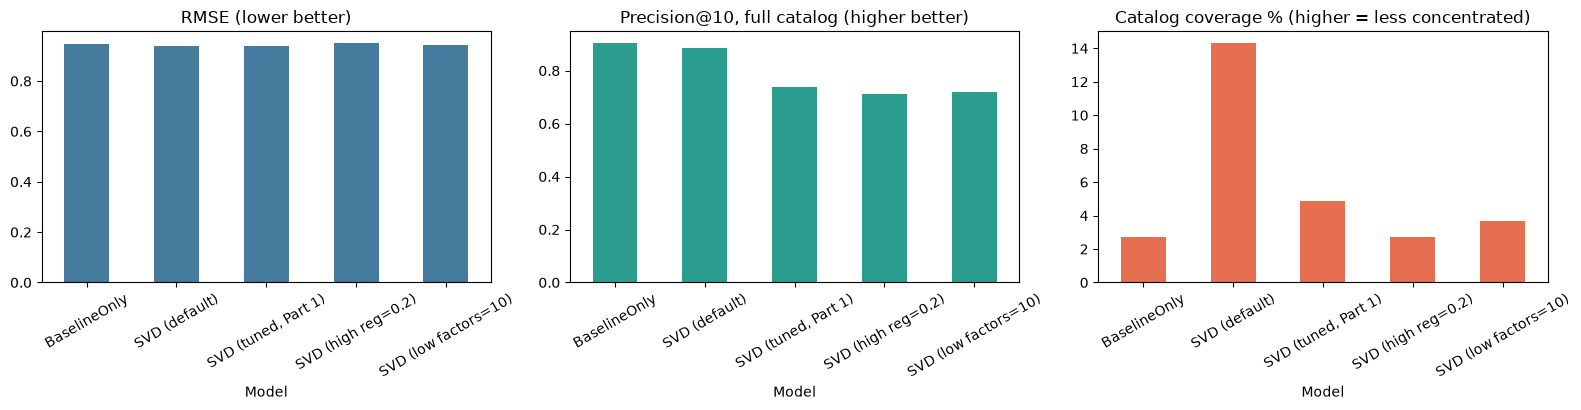


Rank correlation between RMSE ranking and Precision@10 ranking across the 5 configs:
  Spearman rho = 0.300  (p=0.624)  -> these rankings DO NOT reliably agree


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
big_table['RMSE'].plot(kind='bar', ax=axes[0], color='#457b9d'); axes[0].set_title('RMSE (lower better)')
axes[0].tick_params(axis='x', rotation=30)
big_table['Precision@10'].plot(kind='bar', ax=axes[1], color='#2a9d8f'); axes[1].set_title('Precision@10, full catalog (higher better)')
axes[1].tick_params(axis='x', rotation=30)
big_table[['Coverage %']].plot(kind='bar', ax=axes[2], color='#e76f51', legend=False); axes[2].set_title('Catalog coverage % (higher = less concentrated)')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(FIG / '09_rmse_vs_ranking.png', dpi=110); plt.show()
print("\nRank correlation between RMSE ranking and Precision@10 ranking across the 5 configs:")
rmse_rank = big_table['RMSE'].rank()
prec_rank = big_table['Precision@10'].rank(ascending=False)
rho, p = stats.spearmanr(rmse_rank, prec_rank)
print(f"  Spearman rho = {rho:.3f}  (p={p:.3f})  -> {'these rankings agree' if rho > 0.6 else 'these rankings DO NOT reliably agree'}")
RESULTS['point11_rank_agreement'] = dict(spearman_rho=float(rho), p_value=float(p))

## Feedback Point 10 - Fairness: significance testing, not just point estimates
We test whether the RMSE gap by gender (0.98 women vs. 0.92 men in Part 1) is statistically
distinguishable from sampling noise, using a Welch's t-test (unequal variances) on squared errors,
and report exact group sizes. We do the same for a finer-grained age breakdown.

In [29]:
pred_df = pd.DataFrame([{'user_id': p.uid, 'item_id': p.iid, 'actual': p.r_ui, 'est': p.est} for p in pred_tuned])
pred_df = pred_df.merge(users, on='user_id', how='left')
pred_df['sq_err'] = (pred_df.est - pred_df.actual) ** 2

m_err = pred_df.loc[pred_df.gender == 'M', 'sq_err']
f_err = pred_df.loc[pred_df.gender == 'F', 'sq_err']
t_stat, p_val = stats.ttest_ind(f_err, m_err, equal_var=False)
print(f"Gender: RMSE(F)={np.sqrt(f_err.mean()):.4f} (n={len(f_err)})  RMSE(M)={np.sqrt(m_err.mean()):.4f} (n={len(m_err)})")
print(f"  Welch's t-test on squared errors: t={t_stat:.3f}, p={p_val:.4f}  -> "
      f"{'statistically significant at alpha=0.05' if p_val < 0.05 else 'NOT statistically significant at alpha=0.05'}")

pred_df['age_group'] = pd.cut(pred_df.age, [0, 20, 30, 40, 50, 100], labels=['<=20','21-30','31-40','41-50','51+'])
print("\nRMSE by age group (with sample sizes and a one-way ANOVA across groups):")
g = pred_df.groupby('age_group', observed=True)['sq_err']
age_table = pd.DataFrame({'RMSE': np.sqrt(g.mean()), 'n': g.size()}).round(4)
print(age_table.to_string())
groups = [v.values for _, v in pred_df.groupby('age_group', observed=True)['sq_err']]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA across age groups: F={f_stat:.3f}, p={p_anova:.4f}  -> "
      f"{'significant' if p_anova < 0.05 else 'not significant'} at alpha=0.05")
RESULTS['point10_fairness'] = dict(gender_t_stat=float(t_stat), gender_p_value=float(p_val),
                                   gender_significant=bool(p_val < 0.05),
                                   age_anova_f=float(f_stat), age_anova_p=float(p_anova),
                                   age_table=age_table.reset_index().to_dict('records'))

Gender: RMSE(F)=0.9799 (n=6487)  RMSE(M)=0.9246 (n=18513)
  Welch's t-test on squared errors: t=5.243, p=0.0000  -> statistically significant at alpha=0.05

RMSE by age group (with sample sizes and a one-way ANOVA across groups):
             RMSE     n
age_group              
<=20       0.9749  3076
21-30      0.9524  9857
31-40      0.9161  5927
41-50      0.9414  3798
51+        0.8892  2342

One-way ANOVA across age groups: F=7.407, p=0.0000  -> significant at alpha=0.05


## Feedback Point 13 - Reproducibility appendix

In [30]:
import sys, surprise, sklearn, scipy as _scipy
repro = dict(
    python_version=sys.version.split()[0], surprise_version=surprise.__version__,
    pandas_version=pd.__version__, numpy_version=np.__version__, scipy_version=_scipy.__version__,
    sklearn_version=sklearn.__version__, seed=SEED,
    stage1_grid={'n_factors':[50,100],'n_epochs':[20,40],'lr_all':[0.002,0.005]},
    stage2_grid={'reg_all':[0.02,0.04,0.06,0.1]}, final_params=best_params,
    train_ratings=trainset.n_ratings, test_ratings=len(testset),
)
for k, v in repro.items(): print(f"{k:>16}: {v}")
RESULTS['point13_reproducibility'] = repro

  python_version: 3.12.10
surprise_version: 1.1.5
  pandas_version: 3.0.6
   numpy_version: 2.5.3
   scipy_version: 1.18.1
 sklearn_version: 1.9.1
            seed: 42
     stage1_grid: {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005]}
     stage2_grid: {'reg_all': [0.02, 0.04, 0.06, 0.1]}
    final_params: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'random_state': 42, 'reg_all': 0.06}
   train_ratings: 75000
    test_ratings: 25000


## Save all Part 2 results

In [31]:
with open(ROOT / 'results_part2.json', 'w') as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("saved results_part2.json with keys:", list(RESULTS.keys()))

saved results_part2.json with keys: ['point3_4', 'point12_bootstrap', 'point6_cold_start', 'point7_testset_metric', 'point7_full_catalog_metric', 'point9_concentration', 'point11_config_comparison', 'point11_rank_agreement', 'point10_fairness', 'point13_reproducibility']
